#Predicting Nitrogen Concentration in Water Samples Through Tree Regression Modeling

For my Final Project, and considering the requirement that the dataset we use be of local data, I chose to explore the Maryland Open Source database for datasets of interest. I chose to use the "Water Point Source Sample Results" dataset. The dataset was collected by the Maryland Department of the Environment and represents laboratory results of water samples collected at point-source discharge facilities in Maryland from 2008-2013.

Sample measurements include water quality parameters such as the concentration of Nitrogen, Phosphorus, and Ammonia, as well as measurements of total suspended solids (water clarity), Biochemical Oxygen Demand (indicator of bacterial/microorganism growth), and water flow.

My goal for my models is to determine whether total nitrogen concentration may be predicted using the other features measured in each of the samples (Ammonia, phosphorus, BOD, etc.), as Nitrogen has consistently been identified as a pollutant responsible for algal blooms and eutrophication in water sources in the United States, so it'd be interesting to determine how to properly predict it.

Data Source:

Maryland Department of the Environment (MDE), Discharge Monitoring Reports (DMR), Retrieved 5/10/2026. https://opendata.maryland.gov/Energy-and-Environment/Water-Point-Source-Sample-Results/eqs6-savc/about_data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score


## Dataset Preparation

In [2]:
#File is too large for github. I included it in the project folder as a zipped file, but it should be downloaded and added to your workspace for the model to run properly.
df = pd.read_csv("Water_Point_Source_Sample_Results_20260512.csv")

/tmp/ipykernel_11220/1229259199.py:2: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Water_Point_Source_Sample_Results_20260512.csv")


In [3]:
print( "Dataset shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:",df.shape[1])

Dataset shape: (163574, 18)
Rows: 163574
Columns: 18


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 163574 entries, 0 to 163573
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Org Name                   163574 non-null  object 
 1   Station ID                 163574 non-null  object 
 2   County                     163574 non-null  object 
 3   HUC                        163463 non-null  float64
 4   Station Horizontal Datum   163574 non-null  object 
 5   Activity ID                163574 non-null  object 
 6   Activity Start             163574 non-null  object 
 7   Activity Medium            163574 non-null  object 
 8   Activity Type              163574 non-null  object 
 9   Activity Category-Rep Num  163574 non-null  object 
 10  Characteristic Name        163574 non-null  object 
 11  Sample Fraction            163574 non-null  object 
 12  Value Type                 163574 non-null  object 
 13  Result Value Status        16

In [5]:
df.head(10)

,Org Name,Station ID,County,HUC,Station Horizontal Datum,Activity ID,Activity Start,Activity Medium,Activity Type,Activity Category-Rep Num,Characteristic Name,Sample Fraction,Value Type,Result Value Status,Result Value,Units,Analytical Proc ID,Location 1
0,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS903,2012 Mar 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,"Biochemical oxygen demand, standard conditions",Total,Actual,Final,4,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
1,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS903,2012 Mar 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Total suspended solids,Suspended,Actual,Final,2,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
2,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS903,2012 Mar 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Dissolved oxygen (DO),Dissolved,Actual,Final,6,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
3,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS903,2012 Mar 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Ammonia-nitrogen,Total,Actual,Final,0,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
4,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS902,2012 Feb 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Phosphorus,Total,Actual,Final,0.3,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
5,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS902,2012 Feb 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Flow,Total,Actual,Final,11.925,mgd,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
6,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS909,2011 Sep 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Inorganic nitrogen (nitrate and nitrite),Total,Actual,Final,0.7,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
7,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS909,2011 Sep 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Nitrogen,Total,Actual,Final,1.2,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
8,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS909,2011 Sep 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Orthophosphate,Total,Actual,Final,0.1,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"
9,Maryland Point data,MD0021598,ALLEGANY,2070002.0,NAD83,FY12-PS909,2011 Sep 01 12:00:00 AM,Water,Sample-Routine,Sample-Routine,Phosphorus,Total,Actual,Final,0.3,mg/l,MDPOINTSOURCE~MDE-DMR,"MARYLAND (39.623056, -78.754444)"


One issue from working with this dataset is that the characteristics I actually want are not distributed in columns. Instead, the values are all under "Result Value", with the discernment into what's being measured being made in a separate column (Characteristic Name). This means I'll have to not only select the characteristics I want to examine in my models, but also restructure the data so each of the predictors I want to use are in their own columns.

Because I don't need all the variables included in the dataset for my models, I decided to simplify my original dataframe so I could more easily transform it so I had only the characteristics I wanted before I had to transform it into a wide format, with the characteristics in separate columns.

I ran into an error where some measures were entered as strings and Python refused to change to numeric values, so forced coerce and removed any that were not recognized. Still occasionally get an error, which usually clears when I re-run the code a couple of times, even without changing the code. Finally asked Copilot for help troubleshooting and it suggested the below code, which seemed to work.

In [131]:
#df = df[df["Result Value"].apply(lambda x: str(x).replace('.', '', 1).isdigit())]
#df["Result Value"] = df["Result Value"].astype(float)

I re-tested my own code (below) and it looks like it also works, but I'd recommend re-running with either one if an error occurs.

In [6]:
df["Result Value"] = pd.to_numeric(df["Result Value"], errors="coerce")
df = df.dropna(subset=["Result Value"])

In [7]:
#Picked out my target variable - the nitrogen concentration
target = "Nitrogen"
#chose to focus on 6 predictor variables
predictors = [
    "Ammonia-nitrogen", #often co-occurs with nitrogen in fertilizer pollution
    "Phosphorus", #pollution indicator
    "Dissolved oxygen (DO)", #lower oxygen concentrations can be indicators of pollution
    "Biochemical oxygen demand, standard conditions", #can be indicative of algal blooms, etc.
    "Total suspended solids", #sediment presence, ammonia and other pollutants can travel attached to sediments
    "Flow" #water flow - I believe higher water flow would be associated with lower nitrogen and ammonia levels.
]

df_model = df[df["Characteristic Name"].isin([target] + predictors)].copy()

The best way to make sure I split my predictors into column is to group them by sample and then aggregate that data. Individual samples have the same Station ID and Activity Start date so I can group my data by those two variables for each of the predictor variables I want in separate columns.

In [8]:
group_cols = ["Station ID", "Activity Start"] #Identifier for sample

#Building appropriate columns for my focus characteristics
df_wide = (
    df_model
    .groupby(group_cols)
    .agg(
        Nitrogen=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] == "Nitrogen"].mean()
        ),
        Ammonia=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] == "Ammonia-nitrogen"].mean()
        ),
        Phosphorus=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] == "Phosphorus"].mean()
        ),
        Dissolved_Oxygen=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] ==
                        "Dissolved oxygen (DO)"].mean()
        ),
        BOD=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] ==
                        "Biochemical oxygen demand, standard conditions"].mean()
        ),
        TSS=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] ==
                        "Total suspended solids"].mean()
        ),
        Flow=(
            "Result Value",
            lambda x: x[df_model.loc[x.index, "Characteristic Name"] == "Flow"].mean()
        ),
    )
    .reset_index()
)


In [9]:
predictor_cols = ["Ammonia", "Phosphorus", "Dissolved_Oxygen", "BOD", "TSS", "Flow"]
df_wide = df_wide.dropna(subset=predictor_cols) #Making sure I drop empty values for my predictor variables
df_wide.head()

,Station ID,Activity Start,Nitrogen,Ammonia,Phosphorus,Dissolved_Oxygen,BOD,TSS,Flow
0,MD0000311,2008 Aug 01 12:00:00 AM,61.20,19.0,0.72,5.0,5.0,15.0,3.964
1,MD0000311,2008 Dec 01 12:00:00 AM,21.65,19.0,0.18,5.0,9.0,15.0,2.802
2,MD0000311,2008 Jul 01 12:00:00 AM,58.50,14.0,0.21,5.0,8.0,15.0,3.992
3,MD0000311,2008 Nov 01 12:00:00 AM,35.41,8.0,0.19,5.0,16.0,15.0,3.022
4,MD0000311,2008 Oct 01 12:00:00 AM,62.83,14.0,0.33,5.0,8.0,15.0,3.433


This process gives me a dataframe that is a lot slimmer and easier to handle than the data I started with, and that only includes the variables I want.

In [10]:
print( "Dataset shape:", df_wide.shape)
print("Rows:", df_wide.shape[0])
print("Columns:",df_wide.shape[1])

Dataset shape: (14576, 9)
Rows: 14576
Columns: 9


The variables can be described as follows:

In [11]:
pd.DataFrame({
    "Variable Name": ["Station ID","Activity Start","Nitrogen","Ammonia","Phosphorus","Dissolved Oxygen","BOD","TSS","Flow"],
    "Definition": ["Code Identifier for point source measurement station.","Date of sample measurement.","Concentration of Nitrogen (mg/L)","Concentration of Ammonia (mg/L).","Concentration of Phosphorus (mg/L)","Concentration of Oxygen (mg/L)","Biochemical Oxygen Demand, a measure of the amount of dissolved oxygen (DO) required by aerobic microorganisms to decompose organic matter.","Total Suspended Solids, amount of particles suspended in water.","Flow of water (million gallons per day; mdg)"],
    "Variable Type": ["Categorical","Date","Numeric","Numeric","Numeric","Numeric","Numeric","Numeric","Numeric"]
})

,Variable Name,Definition,Variable Type
0,Station ID,Code Identifier for point source measurement s...,Categorical
1,Activity Start,Date of sample measurement.,Date
2,Nitrogen,Concentration of Nitrogen (mg/L),Numeric
3,Ammonia,Concentration of Ammonia (mg/L).,Numeric
4,Phosphorus,Concentration of Phosphorus (mg/L),Numeric
5,Dissolved Oxygen,Concentration of Oxygen (mg/L),Numeric
6,BOD,"Biochemical Oxygen Demand, a measure of the am...",Numeric
7,TSS,"Total Suspended Solids, amount of particles su...",Numeric
8,Flow,Flow of water (million gallons per day; mdg),Numeric


## Exploratory Data Analysis

As part of my exploratory data analysis, I had a closer look at the distribution for my target variable. From the data below, there is an odd grouping of outliers - one group below 200 mg/L, and then another group of outlier measurements that is more spread out, ranging from 200 to just below 1000 mg/L. This second group represents very extreme concentrations of nitrogen. I decided to dig further into these outliers.

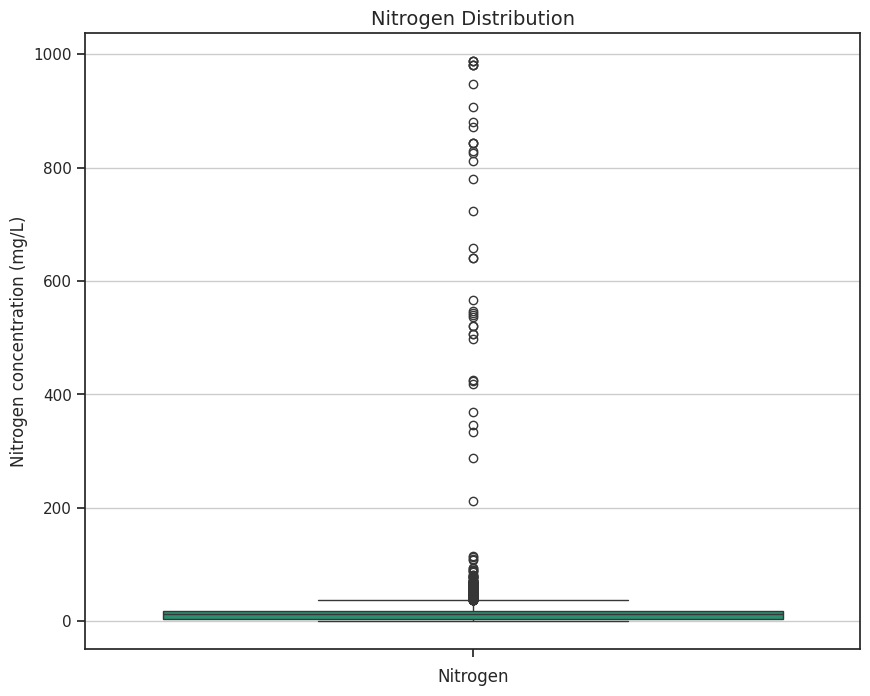

In [12]:
plt.figure(figsize=(10,8))
sns.set_theme(style='ticks')
sns.set_palette('Dark2')
sns.boxplot(data=df_wide,y="Nitrogen")
plt.xlabel('Nitrogen', fontsize=12)
plt.ylabel('Nitrogen concentration (mg/L)', fontsize=12)
plt.title("Nitrogen Distribution", fontsize=14)
plt.grid(axis='y')
plt.show()

 Looking at just the Nitrogen distribution for all stations, below, it is clear that one single station has measurements far above all other. In fact, all outlier measurements above 200 mg/L are coming from that one station.

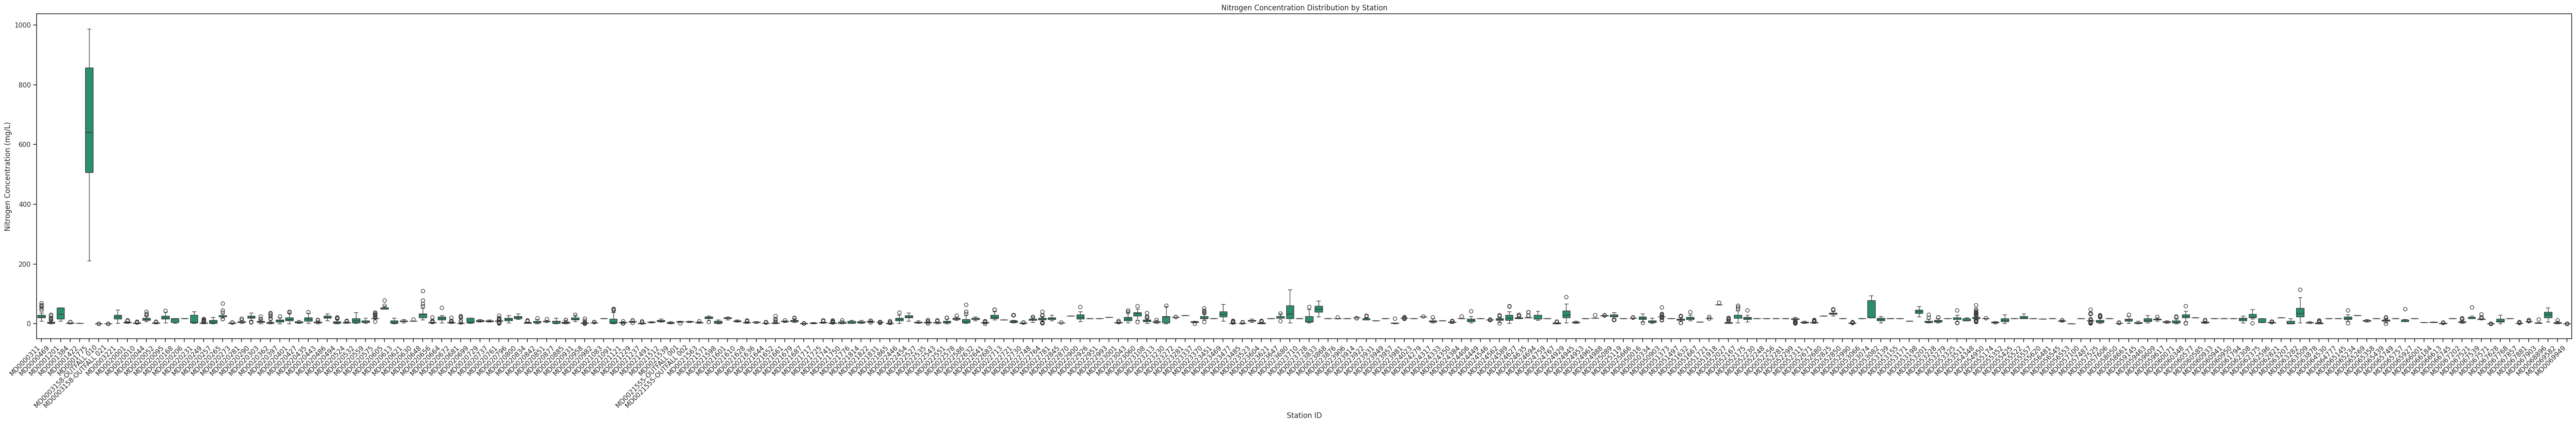

In [13]:
plt.figure(figsize=(60, 10))
sns.set_theme(style='ticks')
sns.set_palette('Dark2')
sns.boxplot(data=df_wide,x="Station ID",y="Nitrogen")
plt.title("Nitrogen Concentration Distribution by Station")
plt.xlabel("Station ID")
plt.ylabel("Nitrogen Concentration (mg/L)")
plt.xticks(rotation=45, ha="right")
plt.grid(False)
plt.tight_layout()
plt.show()


While outliers shouldn't be an issue for tree regressor models, since they handle outliers well, the fact that all the higher concentrations above 200 mg/L come from a single station is slightly worrying. High peaks in nitrogen concentration can correspond to significant pollution events but a single station recording numbers so far above all others may represent an error in data entry or measurement. I decided to exclude this station from my dataset for the sake of modeling nitrogen concentrations in what may be considered standard conditions.



In [14]:
df_wide_clean=df_wide[df_wide['Nitrogen']<=200]

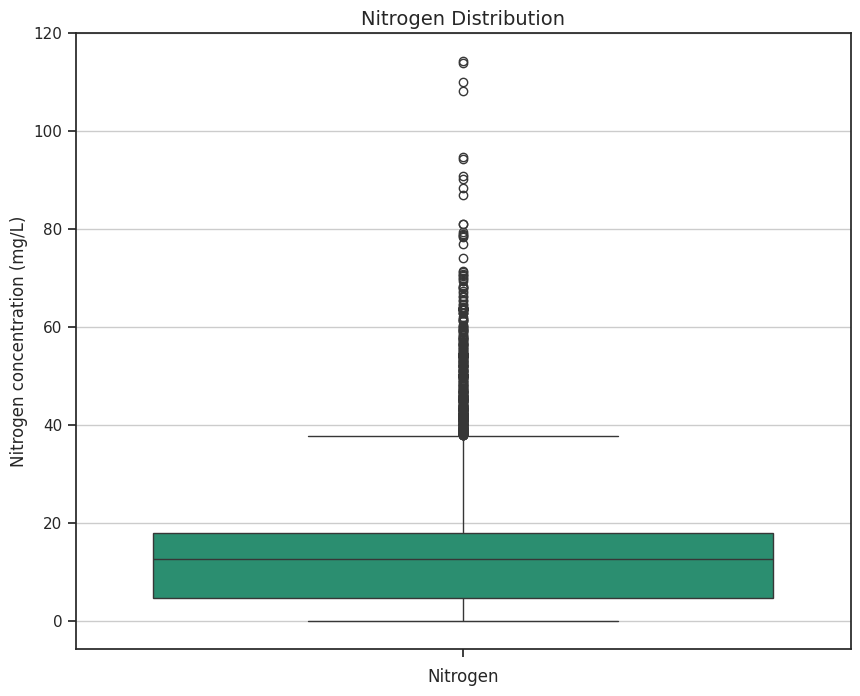

In [15]:
plt.figure(figsize=(10,8))
sns.set_theme(style='ticks')
sns.set_palette('Dark2')
sns.boxplot(data=df_wide_clean,y="Nitrogen")
plt.xlabel('Nitrogen', fontsize=12)
plt.ylabel('Nitrogen concentration (mg/L)', fontsize=12)
plt.title("Nitrogen Distribution", fontsize=14)
plt.grid(axis='y')
plt.show()

The dataset excluding the one station with extreme Nitrogen measurements has more reasonable outliers. Outliers in this case may still represent pollution events, but they are not quite as extreme and should still be handled well by our tree regressor models.

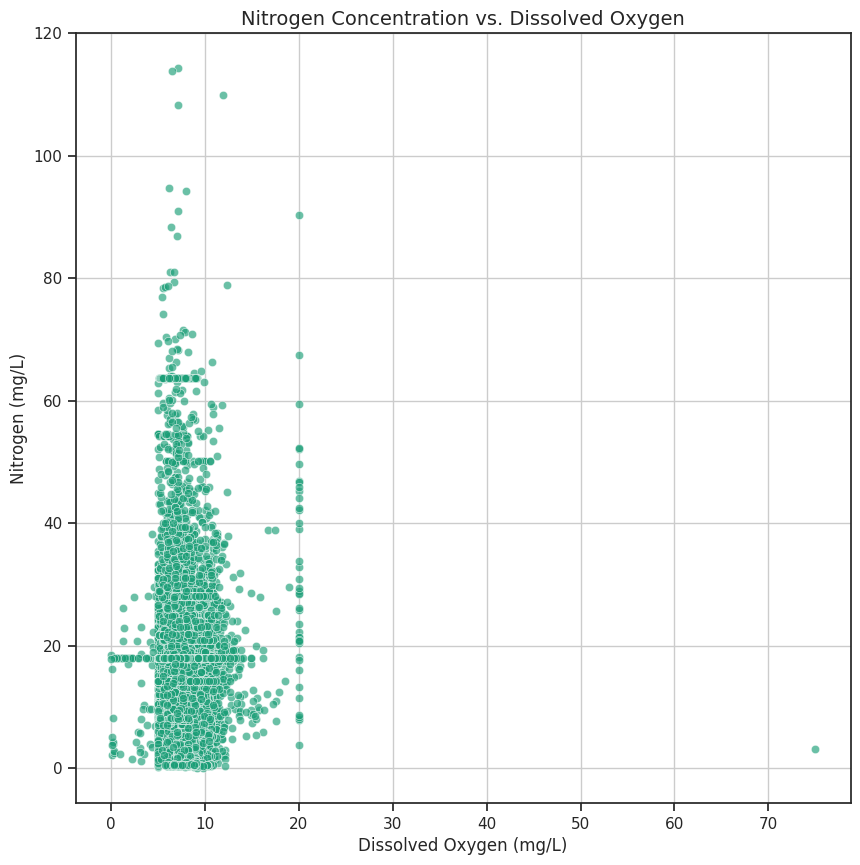

In [16]:
sns.set_palette('Dark2')
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_wide_clean, x='Dissolved_Oxygen', y='Nitrogen', alpha=0.65)
plt.xlabel('Dissolved Oxygen (mg/L)', fontsize=12)
plt.ylabel('Nitrogen (mg/L)', fontsize=12)
plt.title("Nitrogen Concentration vs. Dissolved Oxygen", fontsize=14)
plt.grid()
plt.show()

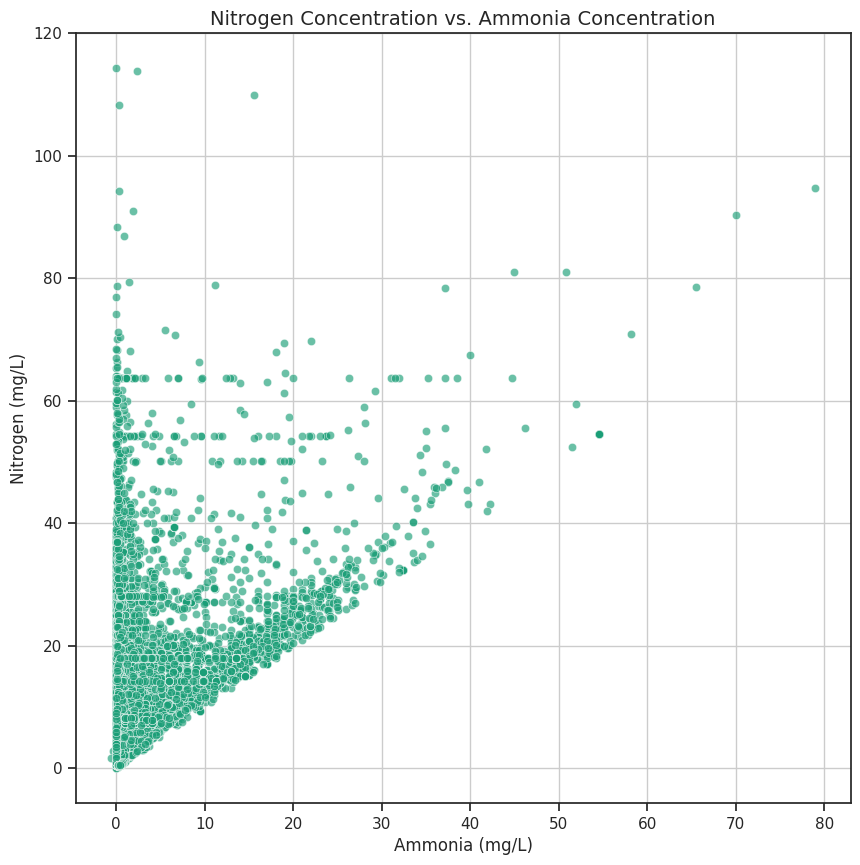

In [17]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_wide_clean, x='Ammonia', y='Nitrogen', alpha=0.65)
plt.xlabel('Ammonia (mg/L)', fontsize=12)
plt.ylabel('Nitrogen (mg/L)', fontsize=12)
plt.title("Nitrogen Concentration vs. Ammonia Concentration", fontsize=14)
plt.grid()
plt.show()

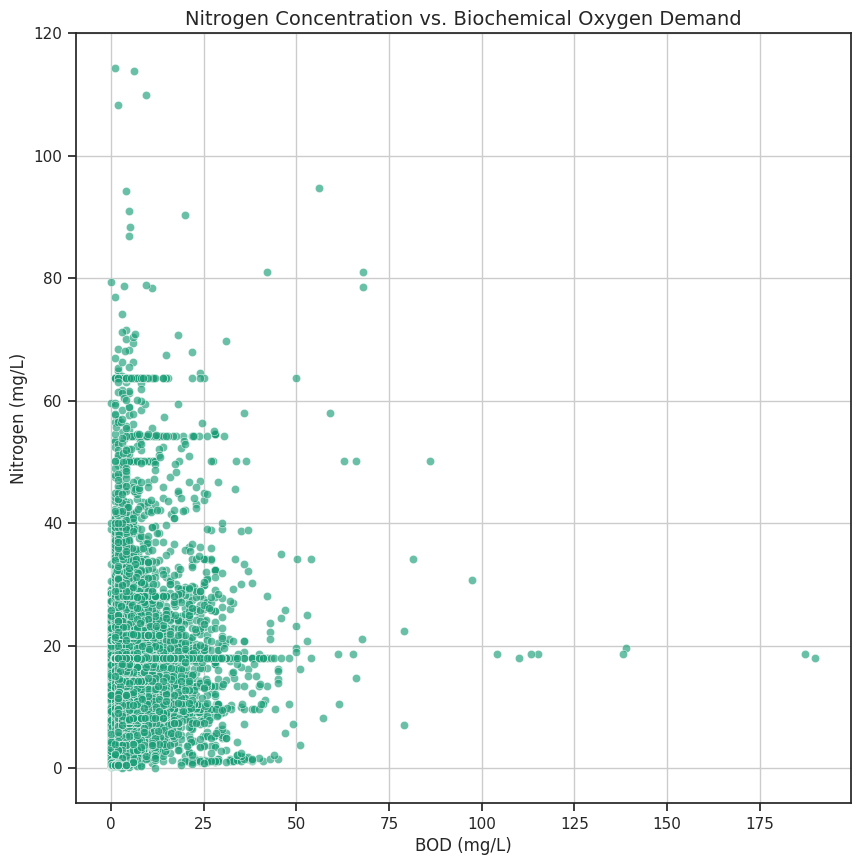

In [18]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_wide_clean, x='BOD', y='Nitrogen', alpha=0.65)
plt.xlabel('BOD (mg/L)', fontsize=12)
plt.ylabel('Nitrogen (mg/L)', fontsize=12)
plt.title("Nitrogen Concentration vs. Biochemical Oxygen Demand", fontsize=14)
plt.grid()
plt.show()

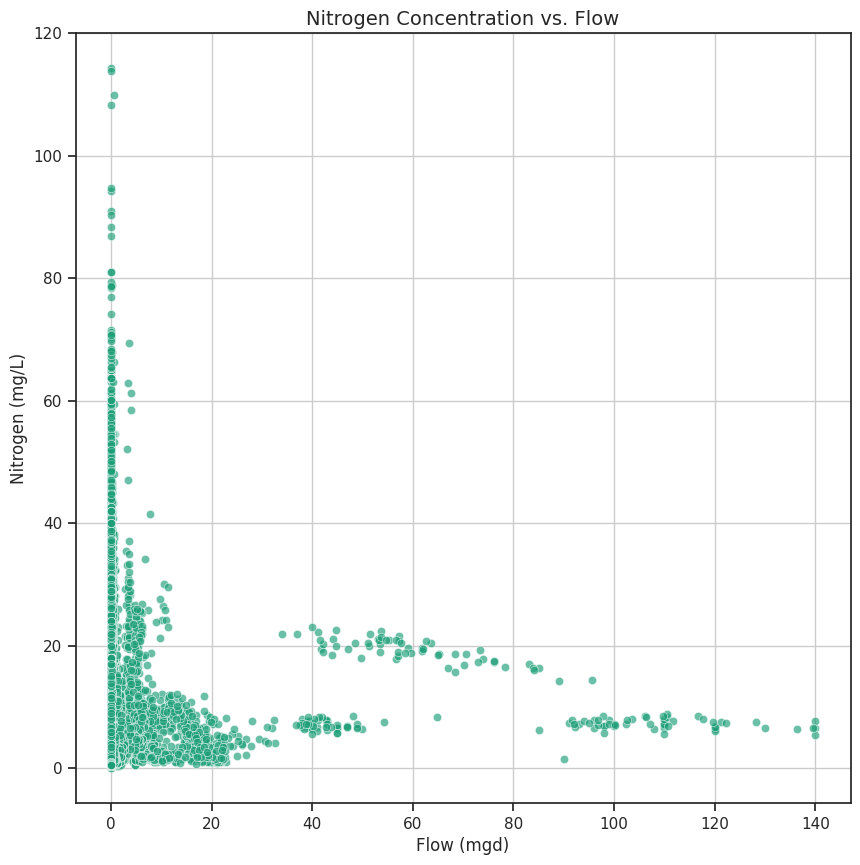

In [19]:
plt.figure(figsize=(10,10))
sns.scatterplot(data=df_wide_clean, x='Flow', y='Nitrogen', alpha=0.65)
plt.xlabel('Flow (mgd)', fontsize=12)
plt.ylabel('Nitrogen (mg/L)', fontsize=12)
plt.title("Nitrogen Concentration vs. Flow", fontsize=14)
plt.grid()
plt.show()

## Decision Tree Analysis

To start my decision tree model, I split my data into training and test data. I chose an 80:20 split as per our usual practice in the course.

In [20]:
X = df_wide_clean[predictor_cols]
y = df_wide_clean["Nitrogen"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


I trained three trees, at depths 3, 6, and 12.

In [21]:
dt3 = DecisionTreeRegressor(max_depth=3, random_state=42)
dt3.fit(X_train, y_train)
preds = dt3.predict(X_test)

print(f"Depth {3}")
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

Depth 3
MSE: 80.068681684777
R2: 0.3438591242916367


In [22]:
dt6 = DecisionTreeRegressor(max_depth=6, random_state=42)
dt6.fit(X_train, y_train)
preds = dt6.predict(X_test)

print(f"Depth {6}")
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

Depth 6
MSE: 67.09121422749062
R2: 0.450205909110995


In [23]:
dt12 = DecisionTreeRegressor(max_depth=12, random_state=42)
dt12.fit(X_train, y_train)
preds = dt12.predict(X_test)

print(f"Depth {12}")
print("MSE:", mean_squared_error(y_test, preds))
print("R2:", r2_score(y_test, preds))

Depth 12
MSE: 69.7797591559573
R2: 0.42817402115397385


Out of the tree tree depths, the depth 6 tree performed best, with the lowest MSE and highest R2.

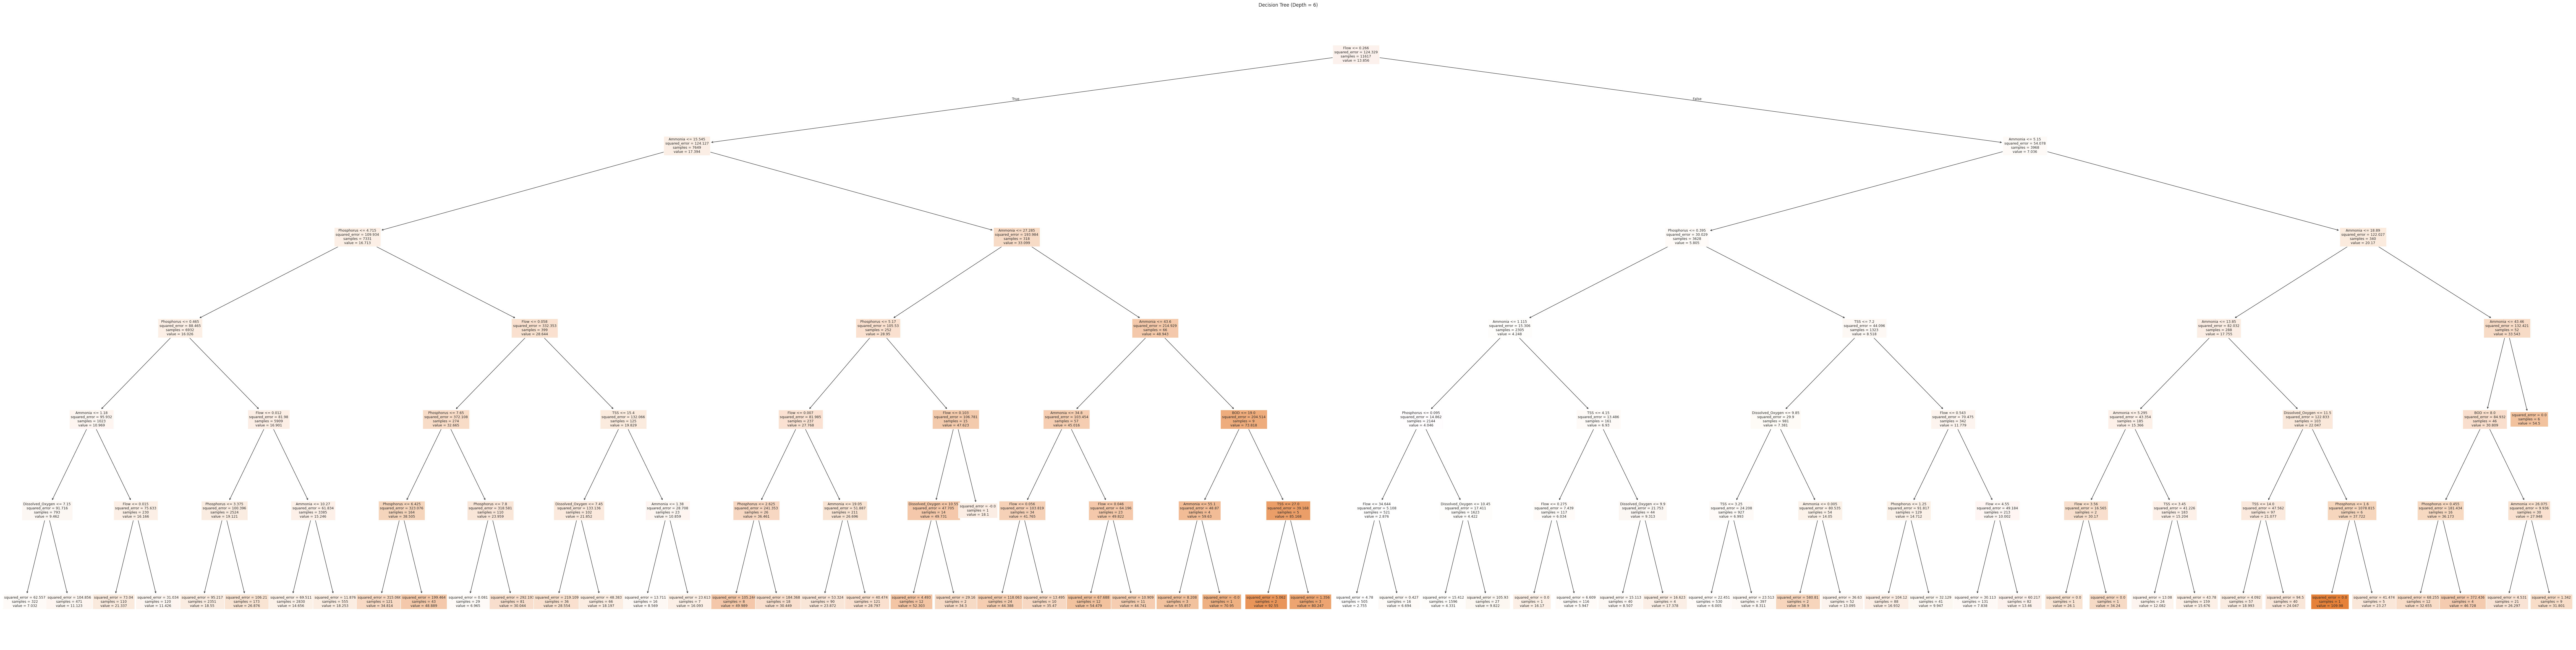

In [24]:
plt.figure(figsize=(120, 30))
plot_tree(
    dt6,
    feature_names=predictor_cols,
    filled=True, fontsize=9)
plt.title("Decision Tree (Depth = 6)")
plt.show()


My root node categorizes based on Flow value as Flow <= .266. If flow is less than the specified value, the second predictor used is the Ammonia concentration, where the tree branches if Ammonia concentration is <= 15.545 mg/L.

## Emsemble Models

I started by running the Random Forest regression and Gradient Boosting models. I also ran a GXBoost model for comparison.  

In [25]:
rf = RandomForestRegressor(random_state=42)
gb = GradientBoostingRegressor(random_state=42)

rf.fit(X_train, y_train)
gb.fit(X_train, y_train)


GradientBoostingRegressor(random_state=42)

In [26]:
!pip install xgboost

In [27]:
import xgboost as xgb

In [28]:
xgbmodel = xgb.XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)


In [29]:
xgbmodel.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

## Model Evaluation

I compared MSE and R2 for all four models to determine the best performing one.

In [30]:
models = {
    "Decision Tree": dt6,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost Model": xgbmodel
}

results = []

for name, model in models.items():
    preds = model.predict(X_test)
    results.append([
        name,
        mean_squared_error(y_test, preds),
        r2_score(y_test, preds)
    ])

results_df = pd.DataFrame(
    results, columns=["Model", "MSE", "R2"]
)

results_df


,Model,MSE,R2
0,Decision Tree,67.091214,0.450206
1,Random Forest,47.930771,0.607220
2,Gradient Boosting,59.670024,0.511021
3,XGBoost Model,55.967398,0.541363


Out of the models used, Random Forest performed best, with the highest R2 and lowest MSE. It is the model that generalized best. It is not as easy to explain as the basic decision tree model, but it outperforms it and can explain the data and predict nitrogen concentration better.

Looking at predicted vs. Actual Nitrogen, there isn't a perfect fit, but there is still an obvious positive correlation.

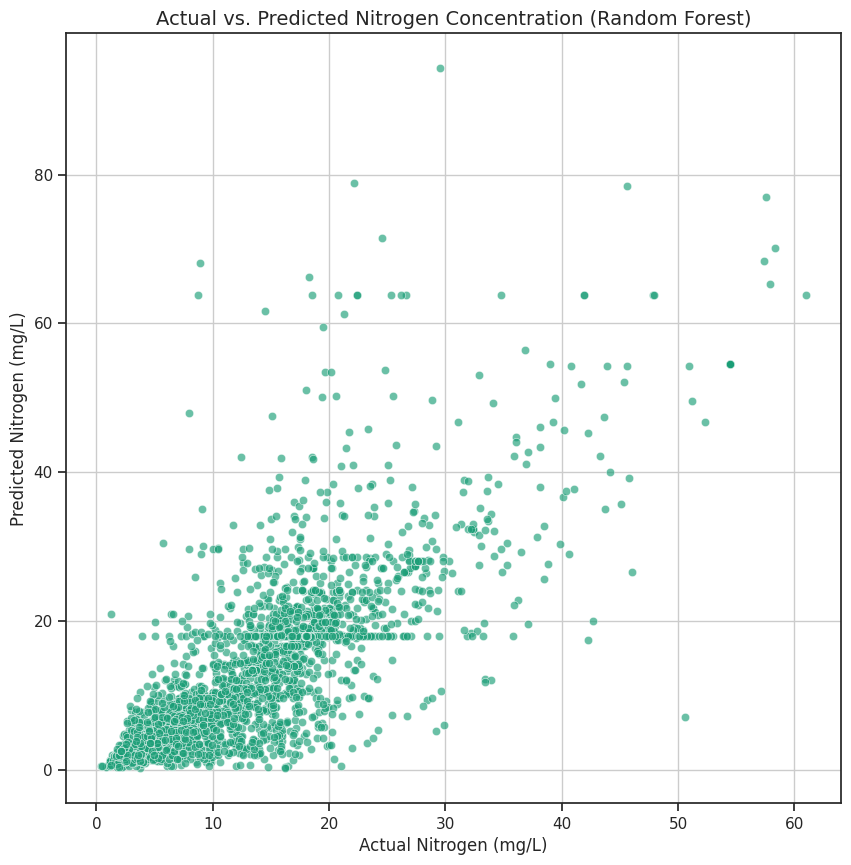

In [31]:
plt.figure(figsize=(10,10))
sns.scatterplot( x=rf.predict(X_test), y=y_test, alpha=0.65)
plt.xlabel('Actual Nitrogen (mg/L)', fontsize=12)
plt.ylabel('Predicted Nitrogen (mg/L)', fontsize=12)
plt.title("Actual vs. Predicted Nitrogen Concentration (Random Forest)", fontsize=14)
plt.grid()
plt.show()

## Feature Importance

As in the single decision tree, Flow was a very significant feature in Nitrogen Concentration for the Random Forest model. Ammonia and Phosphorus coming as second and third, also aligning with the node order I saw in the basic decision tree model.

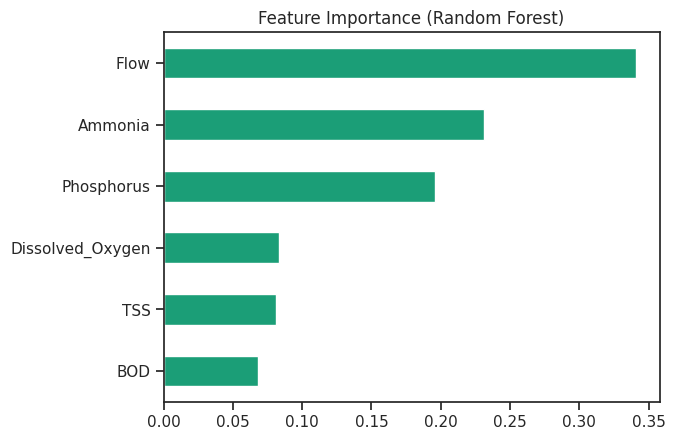

In [32]:
importances = pd.Series(
    rf.feature_importances_,
    index=predictor_cols
).sort_values()

importances.plot(kind="barh")
plt.title("Feature Importance (Random Forest)")
plt.show()


## Final Reflection: Model Battle

The best performing model was the random forest model. While not as easy to explain as a basic tree, it handled the outliers well and has built in measures to reduce potential overfitting. I believe it is a good model for a real-world application, especially in this context because it performs well with noisy data.